# Machine Learning in Science - 2025-2026
- Teacher: Alessandro Corbetta [a.corbetta@tue.nl](mailto:a.corbetta@tue.nl)
- Co-teacher: Chiel van der Laan [c.v.d.laan@tue.nl](mailto:c.v.d.laan@tue.nl)

## [16-03-2025] - Ungraded Assignment: Classifying Reynolds on Lagrangian signals

In this Notebook, we introduce the problem of Reynolds number classification (or equivalently viscosity classification) for Lagrangian signals generated with a shell model of turbulence.

**The goal is, given a lagrangian signal from a shell model simulation, to classify whether the value of the Reynolds number that generated the data is low or high.**
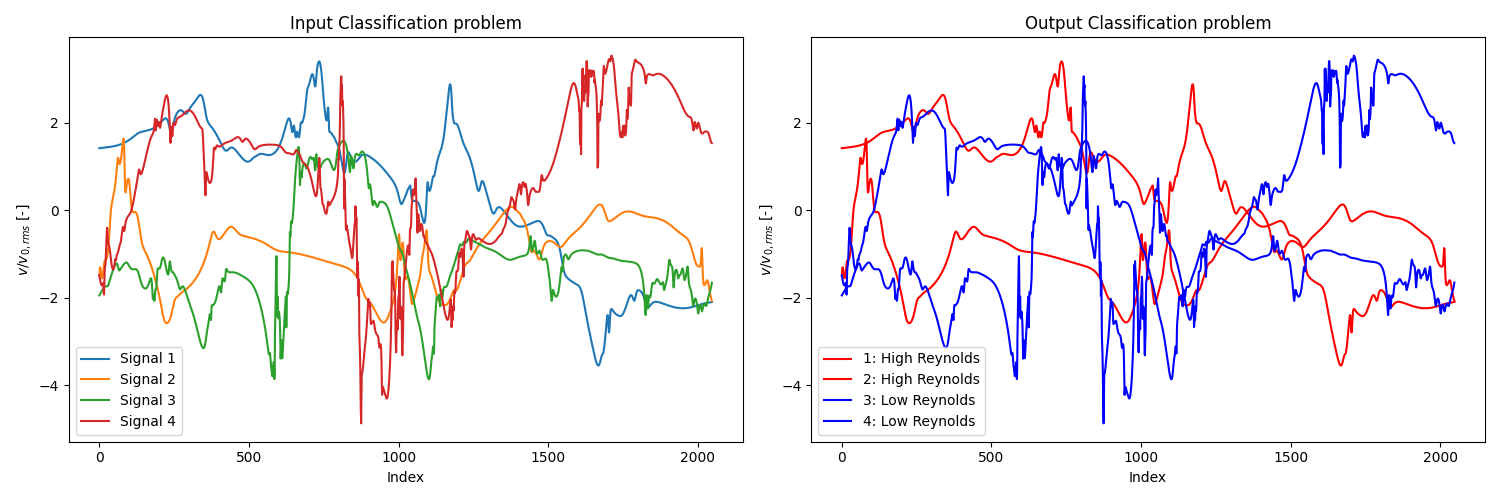

In [1]:
import matplotlib.pyplot as plt
from more_itertools import flatten, windowed

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch import optim

In [2]:
torch.manual_seed(19032025); # reproducibility, but dont use this during your gradeded assignment to get more randomness in your results

In [3]:
print(f'Is cuda available? {'Yes!' if torch.cuda.is_available() else 'No'}')
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)
print(f"{device=}")

Is cuda available? Yes!
device='cuda'


### Import the data

The data is provided as two `.pt` files that each contain a single PyTorch tensor.

In [4]:
class TensorData(Dataset):
    def __init__(self, input_tensor, label_tensor, device="cpu"):
        self.input = input_tensor.to(device)
        self.labels = label_tensor.to(device)

    def __len__(self):
        return self.input.size()[0]

    def __getitem__(self, index):
        return self.input[index], self.labels[index]

In [5]:
x = torch.load("reynolds_input.pt")
y = torch.load("reynolds_labels.pt")

# Add the "channel" dimension
x = x.unsqueeze(1)
# Add the "feature" dimension
y = y.unsqueeze(1)

print(x.shape, y.shape)

torch.Size([20000, 1, 2048]) torch.Size([20000, 1])


Let's take a look at the data and plot some low Reynolds and high Reynolds signals with different colors.

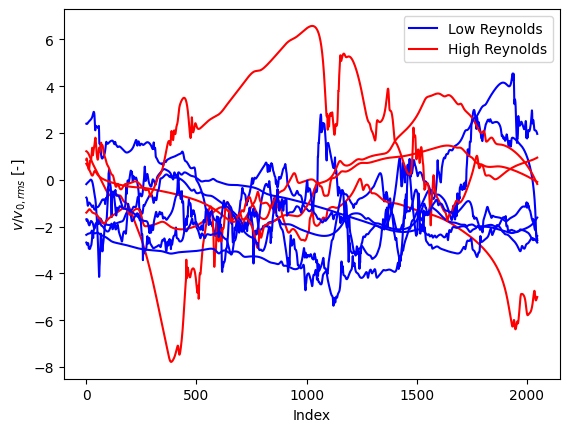

In [6]:
for i in range(10):
    if y[i] == 0:
        plt.plot(x[i, 0, :], color="b")
    else:
        plt.plot(x[i, 0, :], color="r")

plt.plot([], [], color="b", label="Low Reynolds")
plt.plot([], [], color="r", label="High Reynolds")
plt.xlabel('Index')
plt.ylabel(r'$v/v_{0,rms}$ [-]')

plt.legend()
plt.show()

In [7]:
data = TensorData(x, y, device)

In [8]:
# Split the data in a train and test set

num_data = len(data)

train_frac = 0.8  # fraction of the dataset belonging to training set
num_train = int(num_data * train_frac)  # number of training samples
num_test = num_data - num_train  # number of test samples

print(f"Training samples: {num_train}")
print(f"Test samples:     {num_test}")

train, test = torch.utils.data.random_split(data, [num_train, num_test], generator=torch.Generator(device=device))

Training samples: 16000
Test samples:     4000


In [9]:
# Extract the test input and label tensors from the test dataset.

test_input, test_labels = test[:]

test_input = test_input.to(device)
test_labels = test_labels.to(device)

### Define your model

Take these notes into account:
 - Implement a 1D convolutional model to tackle this challenge (the layers of interest are `Conv1D`, `MaxPool1D`, `Dropout`, and `Flatten`).
 - Take inspiration from the model design used in the [original publication](https://doi.org/10.1126/sciadv.aba7281). Figure S.4 in the [supplementary material](https://www.science.org/doi/suppl/10.1126/sciadv.aba7281/suppl_file/aba7281_sm.pdf) provides a schematic overview of the architecture.
 - Note however that the number of parameters required to solve this challenge is much less than the number of parameters used in the paper. The number of parameters can be reduced by reducing the number of convolutional blocks and the number of channels in each convolutional layer. It is adviced to reduce the model to a simpler version like this:

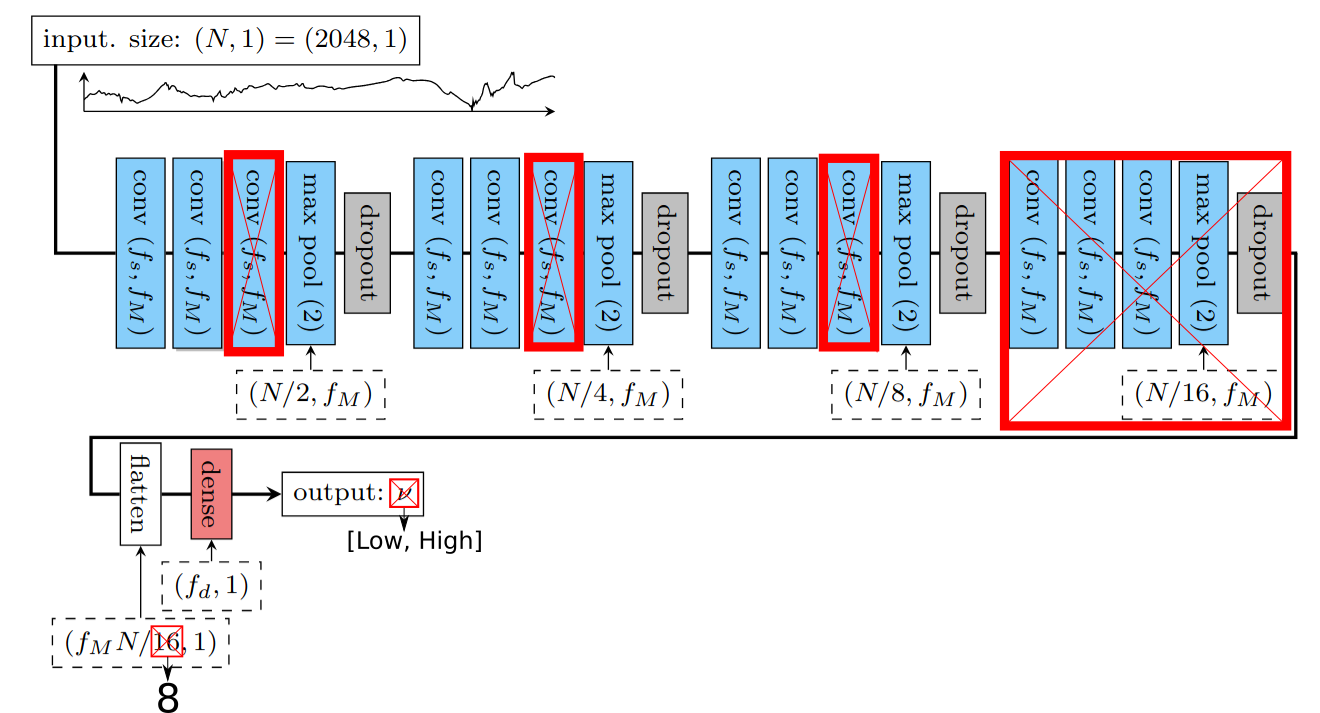

 - As this is a binary classification task, the model prediction should always be a single value between 0 and 1. Lab 6 shows how is implicitly ensured using e.g. the sigmoid function.

In [10]:
# Standard implementation
def make_reynolds_model():
    return nn.Sequential(
        nn.Conv1d(1, 32, kernel_size=3, padding="same"),
        nn.ReLU(),
        nn.Conv1d(32, 32, kernel_size=3, padding="same"),
        nn.ReLU(),
        nn.MaxPool1d(2),
        nn.Dropout(0.2),

        nn.Conv1d(32, 32, kernel_size=3, padding="same"),
        nn.ReLU(),
        nn.Conv1d(32, 32, kernel_size=3, padding="same"),
        nn.ReLU(),
        nn.MaxPool1d(2),
        nn.Dropout(0.2),

        nn.Conv1d(32, 32, kernel_size=3, padding="same"),
        nn.ReLU(),
        nn.Conv1d(32, 32, kernel_size=3, padding="same"),
        nn.ReLU(),
        nn.MaxPool1d(2),
        nn.Dropout(0.2),

        nn.Flatten(),
        nn.Linear(256 * 32, 1),
        nn.Sigmoid()
    )

In [ ]:
# Scalable implementation
def block(channels, kernel_size=3):
    return nn.Sequential(
        *flatten(
            [
                [
                    nn.Conv1d(
                        in_channels,
                        out_channels,
                        kernel_size=kernel_size,
                        padding="same",
                    ),
                    nn.ReLU(),
                ]
                for (in_channels, out_channels) in windowed(channels, 2) 
            ]
        )
    )

# Here we implement the network as a class that inherits from `nn.Module`.
class ViscosityNet(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.conv = nn.Sequential(
            block([1, 32, 32]),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
            block([32, 32, 32]),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
            block([32, 32, 32]),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
        )

        self.dense = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.dense(x)

        return x

### Implement the training loop and train your model

Take note of the following:
 - Use the binary cross-entropy loss as your loss function.
 - When printing, print the train loss, test loss, and the accuracy on the test set.
 - Try to reuse the code from lab 5 as much as possible.
 - When using `Dropout` layers, it is **very** important to switch the model to evaluation mode by calling `model.eval()` before predicting. This will make sure all neurons are used when predicting. The model also needs to be switched back to training mode using `model.train()` before training.
 
 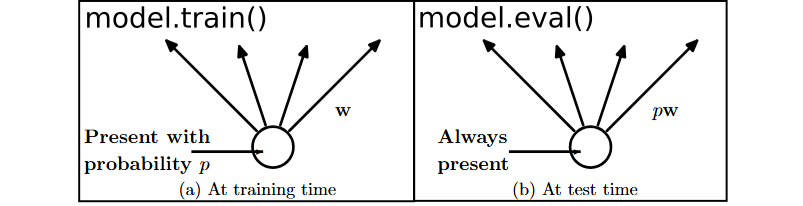
 
 - The dataset is quite substantial, using a GPU for training is advised (you can use Google colab to get access to a free GPU)!

In [12]:
def binary_accuracy(predictions, labels):
    return sum((predictions > 0.5) == labels) / len(labels)

In [13]:
def train_model(
    train_data,
    test_input,
    test_labels,
    model,
    loss_fn,
    accuracy_fn,
    epochs=10,
    lr=0.01,
    batch_size=1,
    print_every=1,
):
    loss_dict = {"train": [], "test": [], "test_acc": []}

    # Initialize optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # We use a `DataLoader` to get batching for free!
    train_data_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, generator=torch.Generator(device=device))

    # Print header.
    print(f"Epoch    Train loss      Test loss       Test accuracy")

    for epoch in range(epochs):
        model.train()

        epoch_loss_sum = 0

        for x_batch, y_batch in train_data_loader:
            # Reset optimizer gradients.
            optimizer.zero_grad()

            # Predict the output
            y_pred = model(x_batch)

            # Compute the loss
            loss = loss_fn(y_pred, y_batch)
            epoch_loss_sum += loss.item()

            # Compute gradients according to newly computed loss.
            loss.backward()

            # Update the model parameters.
            optimizer.step()

        loss_dict["train"].append(epoch_loss_sum / len(train_data_loader))

        with torch.no_grad():
            model.eval()
            test_pred = model(test_input)
            test_loss = loss_fn(test_pred, test_labels)
            loss_dict["test"].append(test_loss.item())

            test_accuracy = accuracy_fn(test_pred, test_labels)
            loss_dict["test_acc"].append(test_accuracy.item())

        if (epoch + 1) % print_every == 0:
            print(
                f"{epoch+1: <7}  {loss_dict['train'][-1]: <14.6e}  {loss_dict['test'][-1]: <13.6e}  {loss_dict['test_acc'][-1]: .6}"
            )

    return model, loss_dict

In [14]:
model = make_reynolds_model().to(device)
# model = ViscosityNet().to(device)

loss_fn = nn.BCELoss()

model, loss_dict = train_model(
    train,
    test_input,
    test_labels,
    model,
    loss_fn,
    binary_accuracy,
    epochs=45,
    lr=5e-4,
    batch_size=64,
    print_every=5,
)

Epoch    Train loss      Test loss       Test accuracy
5        6.931585e-01    6.932126e-01    0.49275
10       6.930451e-01    6.928982e-01    0.5085
15       3.350673e-01    1.585665e-01    0.94425
20       1.252396e-01    1.023523e-01    0.962
25       4.671454e-02    5.244259e-02    0.97825
30       9.758105e-02    7.645424e-02    0.969
35       5.275694e-02    4.204672e-02    0.98375
40       3.134835e-02    2.578087e-02    0.9905
45       3.816381e-02    2.726835e-02    0.98975


### Visualize the model performance

- Plot the loss curves.

In [15]:
def plot_losses(train, test):
    plt.semilogy(train, label="train", marker=".", lw=2)
    plt.semilogy(test, label="test", marker=".", lw=2)
    plt.xlabel("Epoch")
    plt.ylabel("BCE Loss")
    plt.legend()
    plt.show()
def plot_accuracies(test_acc, expected_value_random_guess = 0.5):
    plt.plot(test_acc, label="test accuracy", marker=".", lw=2)
    plt.axhline(expected_value_random_guess, color='red', linestyle='--', label='Random Guess accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

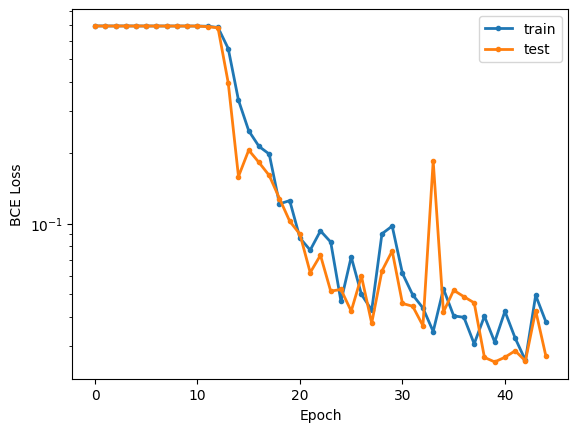

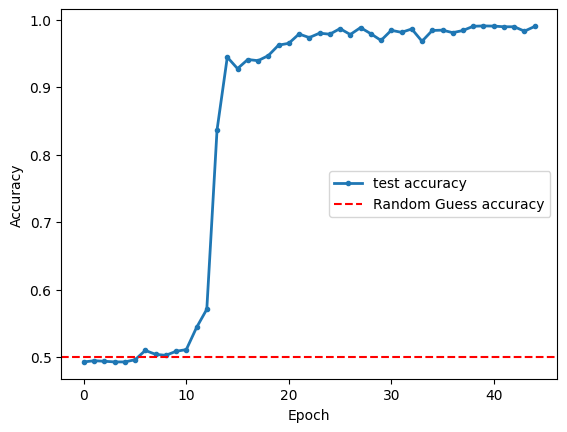

In [17]:
plot_losses(loss_dict["train"], loss_dict["test"])
plot_accuracies(loss_dict['test_acc'],0.5)

In [18]:
with torch.no_grad():
    model.eval()
    y_pred = model(test_input)
    acc = binary_accuracy(y_pred, test_labels).item()
    print(f"Test accuracy: {acc}")

Test accuracy: 0.9897500276565552
